In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

def plot_ica_stats(
    csv_path: str, 
    target_labels: list, 
    threshold: float = 0.90, 
    subject: str = None, 
    condition: str = None
):
    df = pd.read_csv(csv_path)
    df = df[df['Label'].isin(target_labels)]

    if subject:
        df = df[df['Subject'] == subject]
        if condition:
            df = df[df['Condition'] == condition]
            x_column = 'Run'
            main_title = f"{subject} | {condition}"
        else:
            x_column = 'Condition'
            main_title = f"{subject}"
    else:
        x_column = 'Subject'
        main_title = "Все субъекты"

    if df.empty:
        print("Нет данных.")
        return

    df_high = df[df['Probability'] >= threshold]
    df_low  = df[df['Probability'] < threshold]

    def draw_subplot(data, ax, title):
        if data.empty:
            ax.set_title(f"{title}\nНет данных")
            return
        
        counts = data.groupby([x_column, 'Label']).size().unstack(fill_value=0)
        counts.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='black')
        
        ax.set_title(title)
        ax.set_ylabel('Количество найденных компонент')
        ax.set_xlabel(x_column)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title='Метки', bbox_to_anchor=(1.05, 1), loc='upper left')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(main_title, fontsize=16)

    draw_subplot(df_high, axes[0], f"Вероятность >= {threshold}")
    draw_subplot(df_low, axes[1], f"Вероятность < {threshold}")

    plt.tight_layout()
    plt.show()

    fig_box, ax_box = plt.subplots(figsize=(10, 6))
    
    labels_present = df['Label'].unique()
    data_to_plot = [df[df['Label'] == label]['Probability'].values for label in labels_present]
    
    if len(data_to_plot) > 0:
        bplot = ax_box.boxplot(data_to_plot, tick_labels=labels_present, patch_artist=True)
        
        colors = plt.cm.tab10.colors
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
            
        ax_box.set_title(f"Распределение вероятностей ICLabel\n{main_title}")
        ax_box.set_ylabel("Вероятность")
        ax_box.set_xlabel("Тип")
        ax_box.grid(axis='y', linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.show()
    else:
        print("Нет данных для боксплота.")
        plt.close(fig_box)

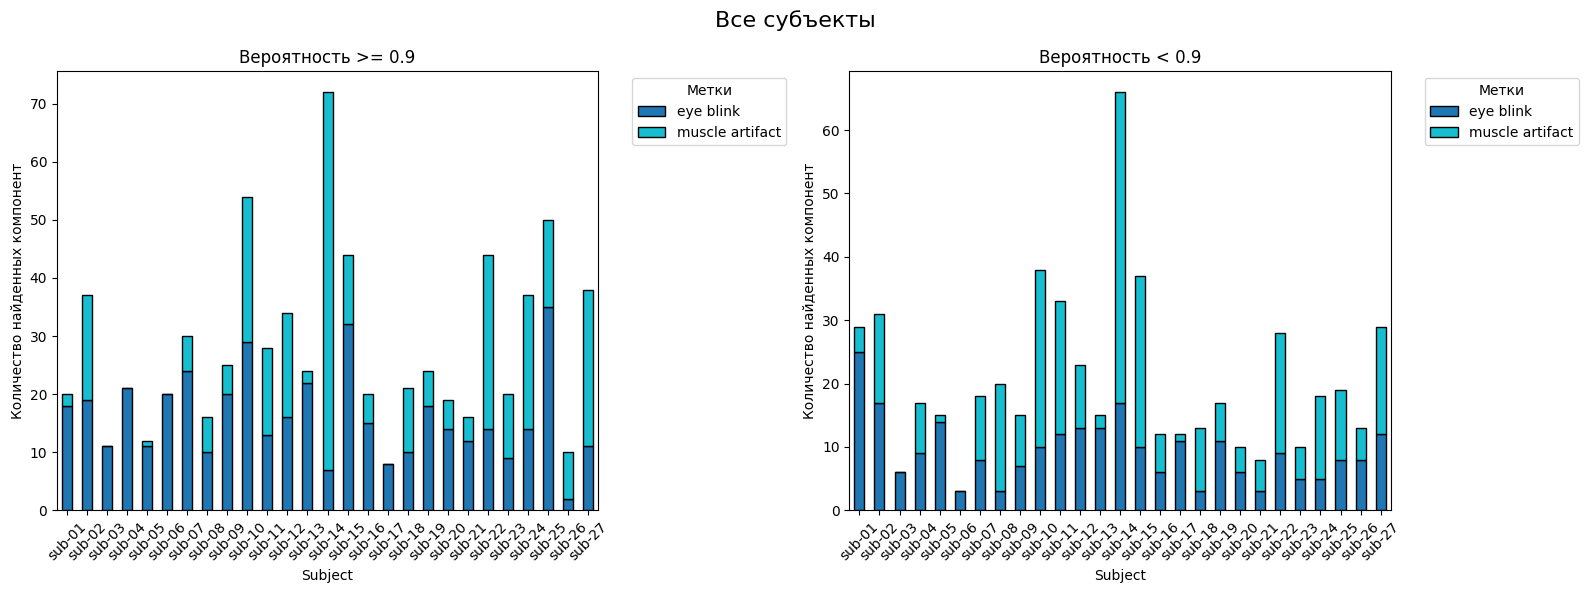

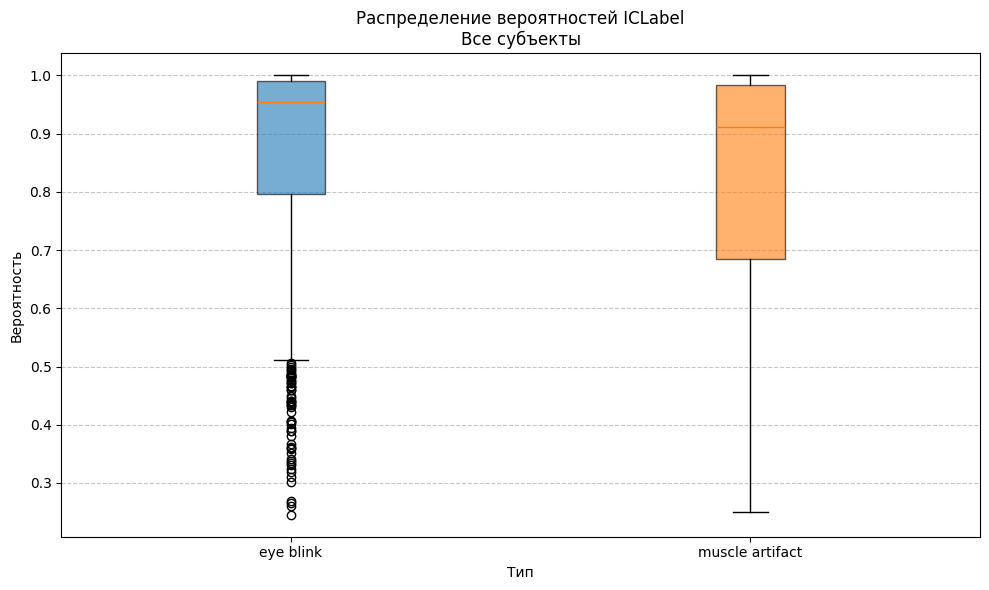

In [2]:
csv_path = "/home/rohin/diplom/results/PEEG/ica_labels_stats.csv"
labels = ["eye blink", "muscle artifact"]
# labels = ["brain", "muscle artifact", "eye blink", "heart beat", "line noise", "channel noise", "other"]
threshold = 0.90

plot_ica_stats(
    csv_path=csv_path,
    target_labels=labels,
    threshold=threshold,
    subject=None, # sub-01
    condition=None # pre, post, follow
)

In [3]:
import os

import matplotlib.pyplot as plt
import mne
import numpy as np
from mne.preprocessing import ICA
from mne_icalabel import label_components

%matplotlib inline
# %matplotlib qt


def plot_ica_help(
    file_path: str, 
    target_labels: list, 
    threshold: float = 0.90, 
):

    raw = mne.io.read_raw_eeglab(file_path, preload=True)

    channels_to_drop = [
        'ECG', 'HEOR', 'HEOL', 'VEOU', 'VEOL',
        'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF8', 'F7', 'F8', 'FT7', 'FT8', 'M1',
        'T7', 'T8', 'M2', 'TP7', 'TP8', 'P7', 'P8', 'PO7', 'PO8', 'CB1', 
        'O1', 'Oz', 'O2'
    ] # M1, M2, CB1 нет в данных
    existing_drop_chs = [ch for ch in channels_to_drop if ch in raw.ch_names]
    if existing_drop_chs:
        raw.drop_channels(existing_drop_chs)

    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, match_case=False, on_missing='ignore')

    raw.set_eeg_reference('average')

    spectrum = raw.compute_psd(method='welch', fmin=1.0, fmax=40.0)
    psds, freqs = spectrum.get_data(return_freqs=True)

    psds_uv = psds * 1e12
    psds_log = 10 * np.log10(psds_uv)
    avg_log_power = np.mean(psds_log, axis=1)

    mean_power_all_channels = np.mean(avg_log_power)
    std_power_all_channels = np.std(avg_log_power)

    z_scores = (avg_log_power - mean_power_all_channels) / std_power_all_channels

    bad_channel_indices = np.where(np.abs(z_scores) > 50)[0]
    bad_channels = [raw.ch_names[i] for i in bad_channel_indices]

    print(f"Плохие каналы для интерполяции: {bad_channels}")

    raw.info['bads'].extend(bad_channels)
    raw.interpolate_bads(reset_bads=True, method='spline')

    raw.resample(sfreq=250.0)

    raw_ica = raw.copy().filter(l_freq=1.0, h_freq=100.0, fir_design='firwin')

    raw = raw.filter(l_freq=3.0, h_freq=35.0, fir_design='firwin')
    raw.notch_filter(freqs=50.0, fir_design='firwin')

    events, event_dict = mne.events_from_annotations(raw)
    target_events = {k: v for k, v in event_dict.items() if k in ['1', '7']}

    epochs_ica = mne.Epochs(raw_ica, events, event_id=target_events, 
                            tmin=9.0, tmax=12.0, 
                            baseline=None, preload=True)

    reject_criteria = dict(eeg=150e-6)
    epochs_ica.drop_bad(reject=reject_criteria)

    ica = ICA(n_components=0.95, method='infomax', fit_params=dict(extended=True), random_state=42)
    ica.fit(epochs_ica)
    ica.plot_sources(raw, show_scrollbars=True, show=True) # plot
    ica.plot_sources(epochs_ica, show_scrollbars=True, show=True) # plot
    ica.plot_components() # plot
    ica.plot_overlay(raw) # plot

    ic_labels = label_components(epochs_ica, ica, method='iclabel')
    labels = ic_labels['labels']
    probabilities = ic_labels['y_pred_proba']
    exclude_idx = []
    print(f"Порог вероятности: {threshold}\nЗначения для удаления: {', '.join(['eye blink', 'muscle artifact'])}")
    for idx, (label, prob) in enumerate(zip(labels, probabilities, strict=False)):
        if label in target_labels and prob >= threshold:
            exclude_idx.append(idx)
            print(f"Компонента {idx:<2}  {label:<16} Вероятность {prob:.2f} УДАЛЕНА")
            # ica.plot_properties(raw, picks=exclude_idx, verbose=False) # plot
            # ica.plot_overlay(raw, exclude=exclude_idx) # plot
        else:
            print(f"Компонента {idx:<2}  {label:<16} Вероятность {prob:.2f}")

    # if exclude_idx:
    #     ica.plot_properties(raw, picks=exclude_idx, verbose=False) # plot
    #     for ex_id in exclude_idx:
    #         ica.plot_overlay(raw, exclude=[ex_id]) # plot
    #     ica.plot_overlay(raw, exclude=exclude_idx) # plot

    if exclude_idx:
        ica.plot_properties(epochs_ica, picks=exclude_idx, verbose=False) # plot
        for ex_id in exclude_idx:
            ica.plot_overlay(raw, exclude=[ex_id]) # plot
        ica.plot_overlay(raw, exclude=exclude_idx) # plot

    ica.exclude = exclude_idx
    raw_clean = ica.apply(raw.copy())

    epochs_clean = mne.Epochs(raw_clean, events, event_id=target_events, 
                        tmin=9.0, tmax=12.0, #tmin=-3.0, tmax=9.0,
                        baseline=None, preload=True)

    epochs_clean.drop_bad(reject=reject_criteria)

    # epochs_clean.save(save_path, overwrite=True)



EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Effective window size : 2.048 (s)
Плохие каналы для интерполяции: []
Setting channel interpolation method to {'eeg': 'spline'}.


/tmp/ipykernel_297773/108065899.py:54: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  raw.interpolate_bads(reset_bads=True, method='spline')


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 3.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 2.00 Hz)
- Upper passband ed

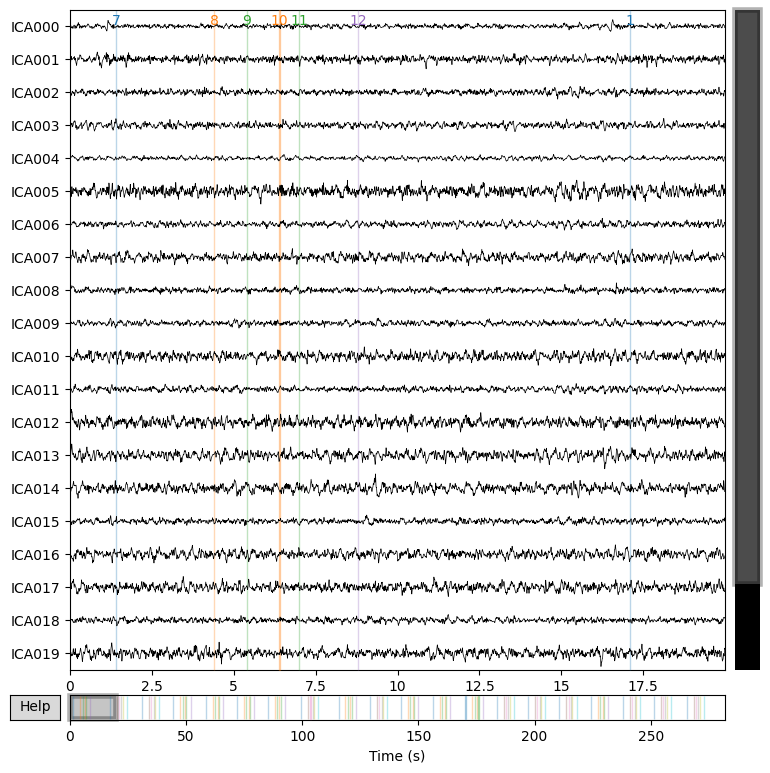

Not setting metadata
20 matching events found
No baseline correction applied
0 projection items activated


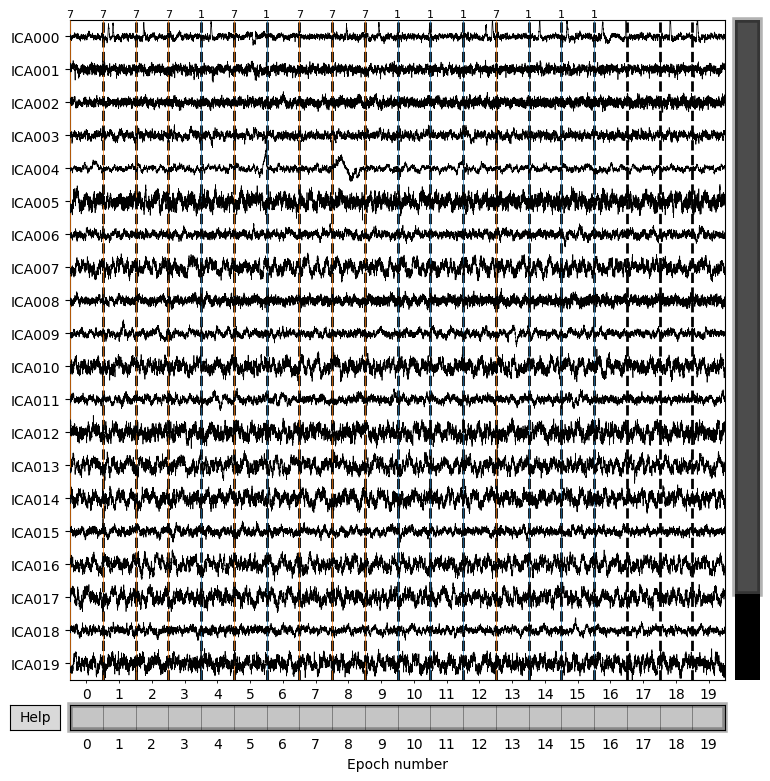

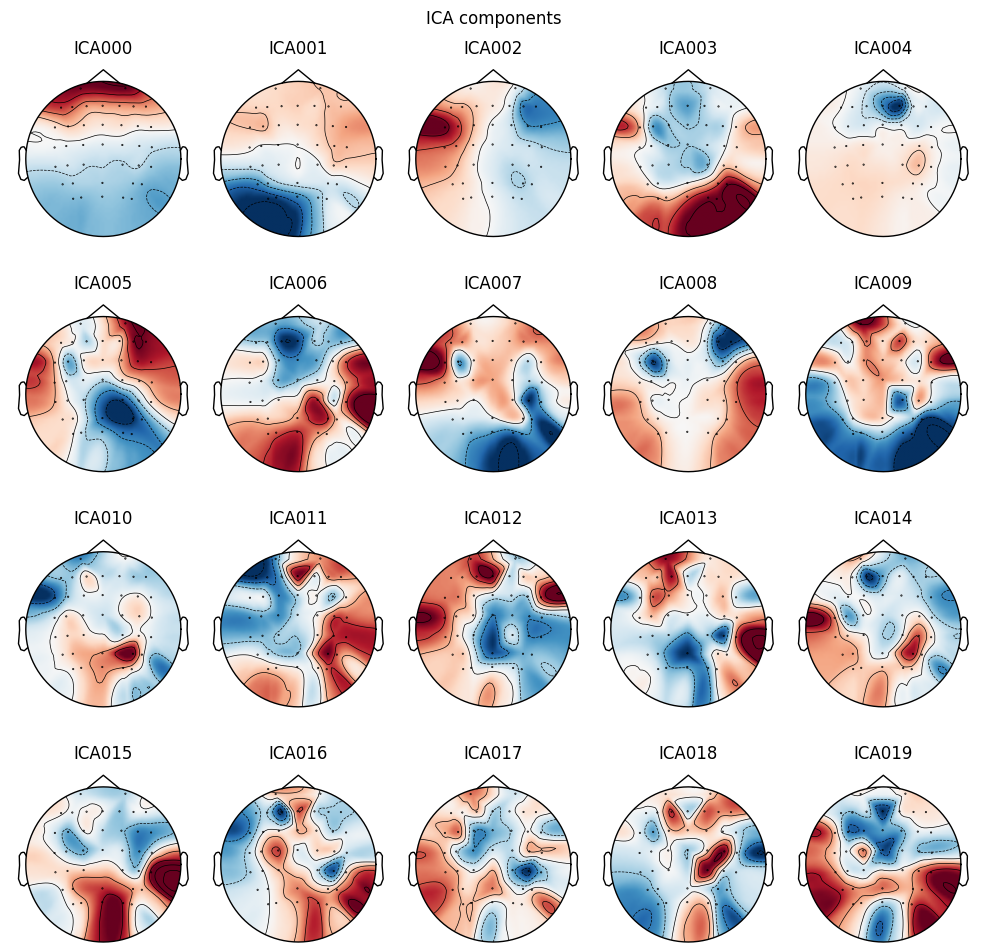

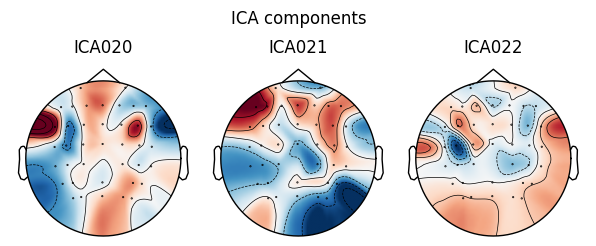

Applying ICA to Raw instance
    Transforming to ICA space (23 components)
    Zeroing out 0 ICA components
    Projecting back using 39 PCA components


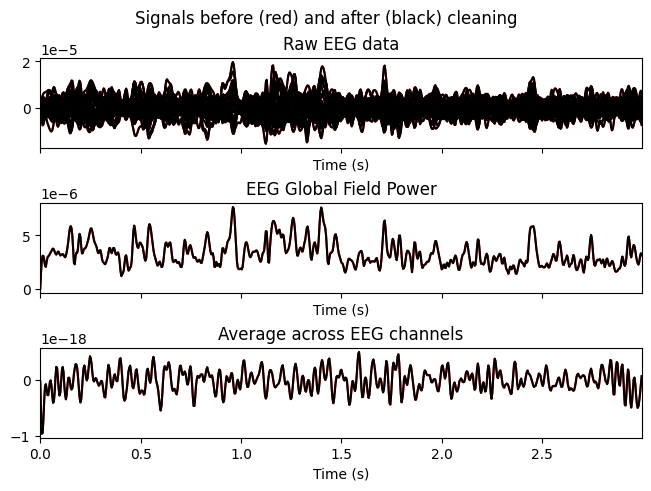

Порог вероятности: 0.9
Значения для удаления: eye blink, muscle artifact
Компонента 0   eye blink        Вероятность 0.98 УДАЛЕНА
Компонента 1   brain            Вероятность 0.98
Компонента 2   eye blink        Вероятность 0.95 УДАЛЕНА
Компонента 3   brain            Вероятность 0.88
Компонента 4   brain            Вероятность 0.48
Компонента 5   brain            Вероятность 0.73
Компонента 6   other            Вероятность 0.67
Компонента 7   other            Вероятность 0.55
Компонента 8   muscle artifact  Вероятность 0.48
Компонента 9   brain            Вероятность 0.51
Компонента 10  brain            Вероятность 0.52
Компонента 11  brain            Вероятность 0.51
Компонента 12  brain            Вероятность 0.70
Компонента 13  other            Вероятность 0.72
Компонента 14  other            Вероятность 0.62
Компонента 15  other            Вероятность 0.85
Компонента 16  other            Вероятность 0.73
Компонента 17  other            Вероятность 0.85
Компонента 18  other         

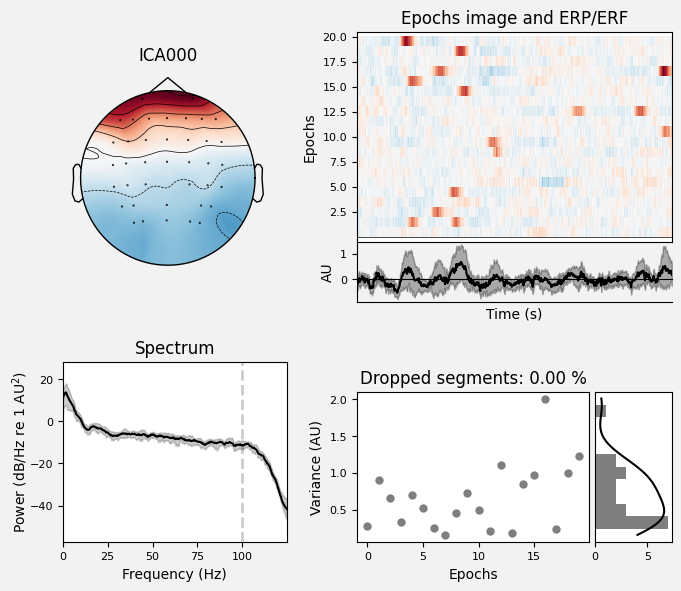

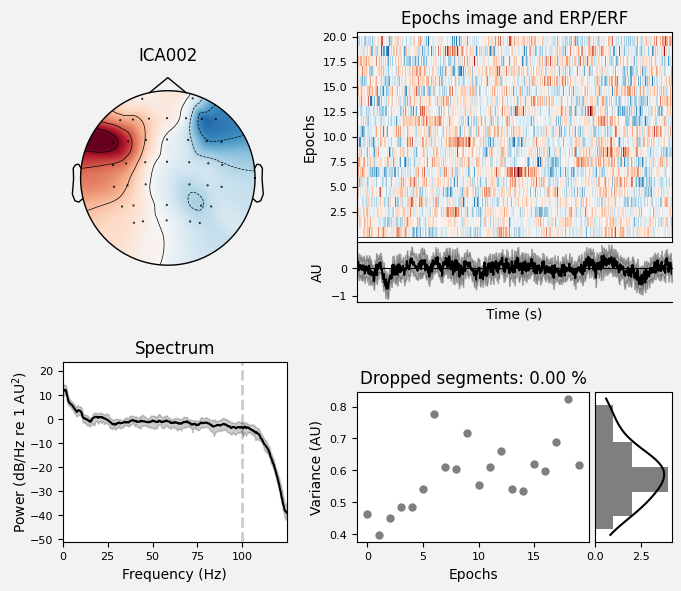

Applying ICA to Raw instance
    Transforming to ICA space (23 components)
    Zeroing out 1 ICA component
    Projecting back using 39 PCA components


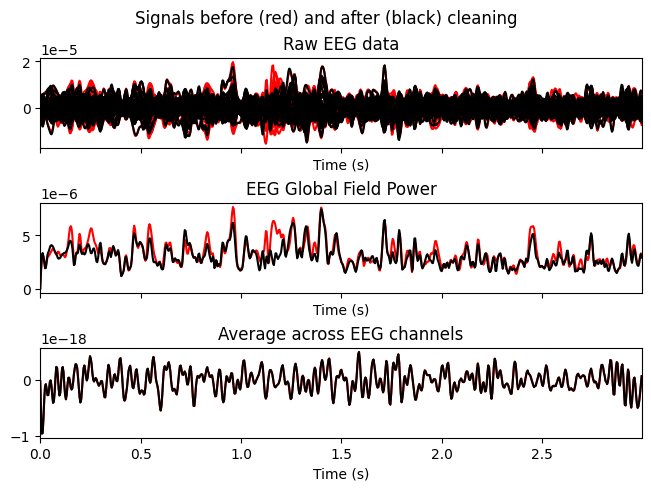

Applying ICA to Raw instance
    Transforming to ICA space (23 components)
    Zeroing out 1 ICA component
    Projecting back using 39 PCA components


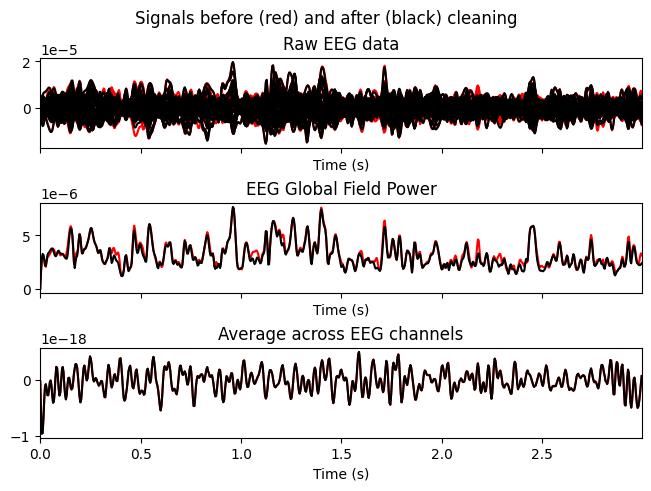

Applying ICA to Raw instance
    Transforming to ICA space (23 components)
    Zeroing out 2 ICA components
    Projecting back using 39 PCA components


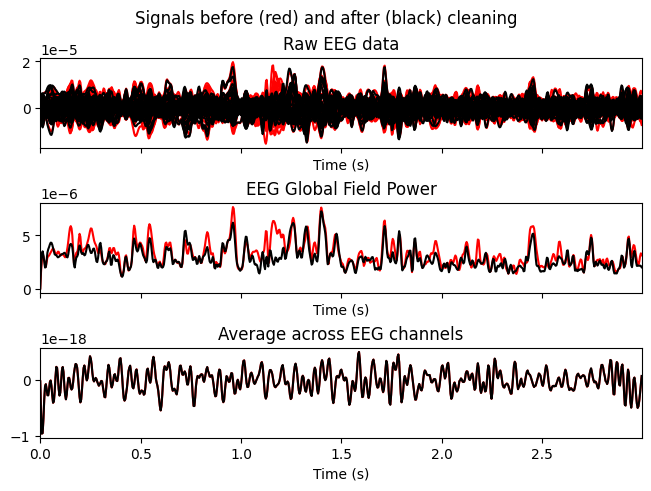

Applying ICA to Raw instance
    Transforming to ICA space (23 components)
    Zeroing out 2 ICA components
    Projecting back using 39 PCA components
Not setting metadata
20 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 20 events and 751 original time points ...
0 bad epochs dropped
0 bad epochs dropped


In [4]:
# file_path = "/mnt/d/diplom/eeg_data/sourcedata/sub-01/ses-5/sub-01_follow_run-3_ori.set"
file_path = "/mnt/d/diplom/eeg_data/sourcedata/sub-01/ses-1/sub-01_pre_run-3_ori.set"
target_labels = ["eye blink", "muscle artifact"]
# brain, muscle artifact, eye blink, heart beat, line noise, channel noise, other
threshold = 0.90

plot_ica_help(
    file_path=file_path,
    target_labels=target_labels,
    threshold=threshold,
)